# One-Time Final Lockbox Evaluation
The model family, Full Direct strategy, features, sampling, preprocessing, parameters, and post-processing were frozen in Step 5 before this notebook accessed lockbox targets. This notebook performs the first and final planned evaluation on `d_1914`–`d_1941`. Results are for generalization assessment only and will not drive tuning or candidate redesign.

## Frozen candidate and issuance information
One global `HistGradientBoostingRegressor` uses raw department-store unit sales, weekly origins aligned backward from `training_end−28` with minimum origin 56, and the Full feature set. At issuance after `d_1913`, historical features end at `d_1913`; calendar/event/SNAP values for target dates are known-in-advance context. Prices are excluded. Predictions are generated and validated for shape before the evaluation file is opened.

In [1]:
from pathlib import Path
import sys,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
from marketmind.forecasting.dataset import CATEGORICAL_COLUMNS,NUMERIC_COLUMNS,build_training_table,build_prediction_table,prepare_calendar,weekly_training_origins
from marketmind.forecasting.metrics import rmsse,mae
TRAIN_END=1913; LOCKBOX_START=1914; LOCKBOX_END=1941; HORIZON=28
TRAIN_DAYS=[f'd_{i}' for i in range(1,TRAIN_END+1)]; LOCKBOX_DAYS=[f'd_{i}' for i in range(LOCKBOX_START,LOCKBOX_END+1)]
PARAMS=dict(loss='squared_error',learning_rate=.05,max_iter=160,max_leaf_nodes=63,max_depth=None,min_samples_leaf=100,l2_regularization=1.,early_stopping=False,random_state=42)
assert len(LOCKBOX_DAYS)==28 and LOCKBOX_DAYS[0]=='d_1914' and LOCKBOX_DAYS[-1]=='d_1941'

## Final training and forecast generation—before target access
This cell reads only `sales_train_validation.csv` through `d_1913`. It builds the frozen training table, fits a fold-local-equivalent encoder and the exact frozen HGBR-4 model, and generates the complete lockbox forecast. The evaluation sales file is deliberately absent from this cell.

In [2]:
sales=pd.read_csv(ROOT/'data/raw/m5/sales_train_validation.csv',usecols=['dept_id','store_id','state_id',*TRAIN_DAYS])
calendar=prepare_calendar(pd.read_csv(ROOT/'data/raw/m5/calendar.csv'))
core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[TRAIN_DAYS].sum().reset_index(); series=core[['state_id','store_id','dept_id']]; training_values=core[TRAIN_DAYS].to_numpy(np.float32)
assert len(core)==70 and training_values.shape==(70,1913) and calendar.loc[1914,'d']=='d_1914' and calendar.loc[1941,'d']=='d_1941'
origins=weekly_training_origins(TRAIN_END); assert origins[-1]+28==TRAIN_END and np.all(origins+28<=TRAIN_END)
started=time.perf_counter(); X_train,y_train=build_training_table(series,training_values,calendar,origins); build_seconds=time.perf_counter()-started
memory_mb=(X_train.memory_usage(deep=True).sum()+y_train.nbytes)/1024**2
encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,encoded_missing_value=-1,dtype=np.float32)
X_encoded=np.column_stack([encoder.fit_transform(X_train[CATEGORICAL_COLUMNS]),X_train[NUMERIC_COLUMNS].to_numpy(np.float32)])
model=HistGradientBoostingRegressor(categorical_features=list(range(len(CATEGORICAL_COLUMNS))),**PARAMS)
started=time.perf_counter(); model.fit(X_encoded,y_train); fit_seconds=time.perf_counter()-started
X_forecast=build_prediction_table(series,training_values,calendar,TRAIN_END)
forecast_encoded=np.column_stack([encoder.transform(X_forecast[CATEGORICAL_COLUMNS]),X_forecast[NUMERIC_COLUMNS].to_numpy(np.float32)])
raw_prediction=model.predict(forecast_encoded).reshape(70,28); prediction=np.clip(raw_prediction,0,None)
forecast_generated=True
assert prediction.shape==(70,28) and prediction.size==1960 and np.isfinite(prediction).all()
training_setup={'origins':len(origins),'rows':len(X_train),'memory_mb':memory_mb,'build_seconds':build_seconds,'fit_seconds':fit_seconds}
training_setup

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_63792/403458478.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[TRAIN_DAYS].sum().reset_index(); series=core[['state_id','store_id','dept_id']]; training_values=core[TRAIN_DAYS].to_numpy(np.float32)


{'origins': 262,
 'rows': 513520,
 'memory_mb': np.float64(159.48334884643555),
 'build_seconds': 4.173508541891351,
 'fit_seconds': 5.820124707883224}

## Consume lockbox targets exactly once
Only after `forecast_generated` is true and the 1,960 predictions are complete does this cell read the 28 evaluation columns. It aligns and aggregates them to the unchanged 70-series grain, then creates the immutable evaluation artifact.

In [3]:
assert forecast_generated and prediction.shape==(70,28)
evaluation=pd.read_csv(ROOT/'data/raw/m5/sales_train_evaluation.csv',usecols=['dept_id','store_id','state_id',*LOCKBOX_DAYS])
lockbox=evaluation.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[LOCKBOX_DAYS].sum().reset_index()
assert lockbox[['state_id','store_id','dept_id']].equals(series.reset_index(drop=True))
actual=lockbox[LOCKBOX_DAYS].to_numpy(np.float32); assert actual.shape==(70,28)
dates=calendar.loc[np.arange(LOCKBOX_START,LOCKBOX_END+1),'date'].dt.strftime('%Y-%m-%d').to_numpy()
artifact=pd.DataFrame({
 'store_id':np.repeat(series.store_id.to_numpy(),28),'dept_id':np.repeat(series.dept_id.to_numpy(),28),'state_id':np.repeat(series.state_id.to_numpy(),28),
 'd':np.tile(LOCKBOX_DAYS,70),'date':np.tile(dates,70),'forecast_horizon':np.tile(np.arange(1,29),70),
 'actual':actual.ravel(),'prediction':prediction.ravel(),'error':(prediction-actual).ravel(),
})
artifact_dir=ROOT/'reports/forecasting/artifacts'; artifact_dir.mkdir(parents=True,exist_ok=True); artifact.to_csv(artifact_dir/'lockbox_forecasts.csv',index=False)
assert len(artifact)==1960 and artifact.d.nunique()==28 and artifact[['store_id','dept_id']].drop_duplicates().shape[0]==70
artifact.head()

,store_id,dept_id,state_id,d,date,forecast_horizon,actual,prediction,error
0,CA_1,FOODS_1,CA,d_1914,2016-04-25,1,294.0,260.003635,-33.996365
1,CA_1,FOODS_1,CA,d_1915,2016-04-26,2,259.0,257.979721,-1.020279
2,CA_1,FOODS_1,CA,d_1916,2016-04-27,3,268.0,282.305537,14.305537
3,CA_1,FOODS_1,CA,d_1917,2016-04-28,4,328.0,284.935118,-43.064882
4,CA_1,FOODS_1,CA,d_1918,2016-04-29,5,387.0,347.994290,-39.005710


## Final metrics and frozen baselines
RMSSE scales use only `d_1`–`d_1913`. Baselines retain their frozen definitions and provide interpretation only: final 28-day mean, repeated final seven days, and final value. Their results cannot alter the frozen HGBR.

In [4]:
forecasts={'Frozen HGBR-4 Direct':prediction,'Historical mean 28':np.repeat(training_values[:,-28:].mean(1)[:,None],28,axis=1),'Seasonal naive 7':np.tile(training_values[:,-7:],(1,4)),'Last value':np.repeat(training_values[:,-1,None],28,axis=1)}
metric_rows=[]
for name,forecast in forecasts.items():
 for i,item in series.reset_index(drop=True).iterrows(): metric_rows.append({**item.to_dict(),'model':name,'rmsse':rmsse(actual[i],forecast[i],training_values[i]),'mae':mae(actual[i],forecast[i]),'absolute_error':np.abs(actual[i]-forecast[i]).sum(),'signed_error':(forecast[i]-actual[i]).sum(),'actual_total':actual[i].sum()})
metrics=pd.DataFrame(metric_rows)
summary=metrics.groupby('model').agg(macro_rmsse=('rmsse','mean'),median_rmsse=('rmsse','median'),q25_rmsse=('rmsse',lambda x:x.quantile(.25)),q75_rmsse=('rmsse',lambda x:x.quantile(.75)),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),signed_error=('signed_error','sum'),actual_total=('actual_total','sum')).reset_index()
summary['pooled_wape']=summary.absolute_error/summary.actual_total; summary['pooled_bias']=summary.signed_error/summary.actual_total
summary.drop(columns=['absolute_error','signed_error','actual_total']).sort_values('macro_rmsse')

,model,macro_rmsse,median_rmsse,q25_rmsse,q75_rmsse,macro_mae,pooled_wape,pooled_bias
0,Frozen HGBR-4 Direct,0.800726,0.716859,0.539486,0.966727,60.128788,0.095678,-0.047614
3,Seasonal naive 7,1.027374,0.885006,0.692375,1.366681,83.007143,0.132082,-0.073592
1,Historical mean 28,1.153377,1.081065,0.925176,1.291343,105.069059,0.167187,-0.039081
2,Last value,1.492516,1.334602,1.119069,1.727730,151.742857,0.241455,0.131921


## Generalization gap and series/group results
Development-to-lockbox differences are generalization gaps, not automatically overfitting. Series wins compare the frozen model with each baseline on the same series. Group summaries are descriptive and do not trigger changes.

In [5]:
lockbox_rmsse=float(summary.loc[summary.model=='Frozen HGBR-4 Direct','macro_rmsse'].iloc[0]); development={'rmsse':.74604,'mae':57.35,'wape':.1029,'bias':-.0037}
gap={'absolute_rmsse':lockbox_rmsse-development['rmsse'],'relative_rmsse_pct':100*(lockbox_rmsse-development['rmsse'])/development['rmsse']}
print('generalization gap',gap)
scores=metrics.pivot(index=['state_id','store_id','dept_id'],columns='model',values='rmsse'); learned=scores['Frozen HGBR-4 Direct']
print('beats historical',int((learned<scores['Historical mean 28']).sum()),'beats seasonal',int((learned<scores['Seasonal naive 7']).sum()),'beats last',int((learned<scores['Last value']).sum()))
display(learned.sort_values().head(10).rename('rmsse').to_frame()); display(learned.sort_values().tail(10).rename('rmsse').to_frame())
for group in ['dept_id','store_id','state_id']: display(metrics[metrics.model=='Frozen HGBR-4 Direct'].groupby(group).rmsse.mean().sort_values().rename('macro_rmsse').to_frame())
display(learned.loc[[('CA','CA_4','HOBBIES_2'),('CA','CA_2','FOODS_2'),('TX','TX_1','HOBBIES_2')]].rename('rmsse').to_frame())

generalization gap {'absolute_rmsse': 0.05468622285143587, 'relative_rmsse_pct': 7.330199835321949}
beats historical 65 beats seasonal 62 beats last 61


rmsse
state_id store_id dept_id              
CA       CA_1     HOUSEHOLD_1  0.311178
WI       WI_1     FOODS_3      0.339484
CA       CA_1     FOODS_2      0.368606
TX       TX_2     HOUSEHOLD_2  0.369648
CA       CA_3     FOODS_3      0.382992
         CA_1     FOODS_3      0.388784
WI       WI_3     FOODS_3      0.401063
TX       TX_2     FOODS_3      0.403240
CA       CA_3     HOBBIES_1    0.409363
WI       WI_1     HOBBIES_1    0.412110

rmsse
state_id store_id dept_id            
CA       CA_2     HOBBIES_2  1.194822
                  FOODS_2    1.246119
TX       TX_3     HOBBIES_2  1.313006
         TX_1     HOBBIES_2  1.351809
CA       CA_4     FOODS_1    1.437560
TX       TX_1     FOODS_1    1.467672
         TX_3     FOODS_1    1.526687
WI       WI_3     FOODS_1    1.717446
CA       CA_3     HOBBIES_2  1.776637
WI       WI_2     FOODS_1    1.820317

,macro_rmsse
dept_id,
FOODS_3,0.494516
HOUSEHOLD_1,0.609499
HOBBIES_1,0.658778
FOODS_2,0.699007
HOUSEHOLD_2,0.701446
HOBBIES_2,1.139403
FOODS_1,1.302434


,macro_rmsse
store_id,
CA_1,0.536276
WI_1,0.650753
TX_2,0.653450
WI_3,0.778535
CA_3,0.847763
TX_1,0.862324
CA_4,0.864943
CA_2,0.875141
TX_3,0.904568


,macro_rmsse
state_id,
CA,0.781031
TX,0.806781
WI,0.820932


rmsse
state_id store_id dept_id            
CA       CA_4     HOBBIES_2  0.896852
         CA_2     FOODS_2    1.246119
TX       TX_1     HOBBIES_2  1.351809

## Horizon and prediction sanity
Block MAE and signed bias describe horizon behavior. Sanity checks report raw bounds, clipping, non-finite values, and exact output count without silent repair.

In [6]:
horizon=pd.DataFrame({'horizon':np.tile(np.arange(1,29),70),'actual':actual.ravel(),'prediction':prediction.ravel()}); horizon['error']=horizon.prediction-horizon.actual; horizon['block']=pd.cut(horizon.horizon,[0,7,14,21,28],labels=['1-7','8-14','15-21','22-28'])
blocks=horizon.groupby('block',observed=True).agg(mae=('error',lambda x:x.abs().mean()),absolute_error=('error',lambda x:x.abs().sum()),signed_error=('error','sum'),actual_total=('actual','sum')).reset_index(); blocks['wape']=blocks.absolute_error/blocks.actual_total; blocks['bias']=blocks.signed_error/blocks.actual_total; display(blocks.drop(columns=['absolute_error','signed_error','actual_total']))
daily=horizon.groupby('horizon').agg(mae=('error',lambda x:x.abs().mean()),signed_error=('error','sum'),actual_total=('actual','sum')).reset_index(); daily['bias']=daily.signed_error/daily.actual_total; display(daily[['horizon','mae','bias']])
sanity={'total_predictions':raw_prediction.size,'raw_min':float(raw_prediction.min()),'raw_max':float(raw_prediction.max()),'negative_raw':int((raw_prediction<0).sum()),'changed_by_clipping':int((raw_prediction!=prediction).sum()),'clipping_rate':float((raw_prediction!=prediction).mean()),'nan_count':int(np.isnan(raw_prediction).sum()),'infinite_count':int(np.isinf(raw_prediction).sum())}; sanity

,block,mae,wape,bias
0,1-7,50.546617,0.085461,-0.023419
1,8-14,57.893366,0.091065,-0.034542
2,15-21,66.701418,0.100002,-0.065832
3,22-28,65.373751,0.105509,-0.064510


,horizon,mae,bias
0,1,45.809649,-0.047168
1,2,39.806893,-0.019187
2,3,42.128012,0.016248
3,4,42.229032,0.009225
4,5,61.714395,-0.051611
5,6,61.663645,-0.028202
6,7,60.474694,-0.028673
7,8,45.831001,-0.015745
8,9,64.548404,-0.068146
9,10,51.601042,-0.055963


{'total_predictions': 1960,
 'raw_min': 13.03767085091103,
 'raw_max': 3600.9411279830797,
 'negative_raw': 0,
 'changed_by_clipping': 0,
 'clipping_rate': 0.0,
 'nan_count': 0,
 'infinite_count': 0}

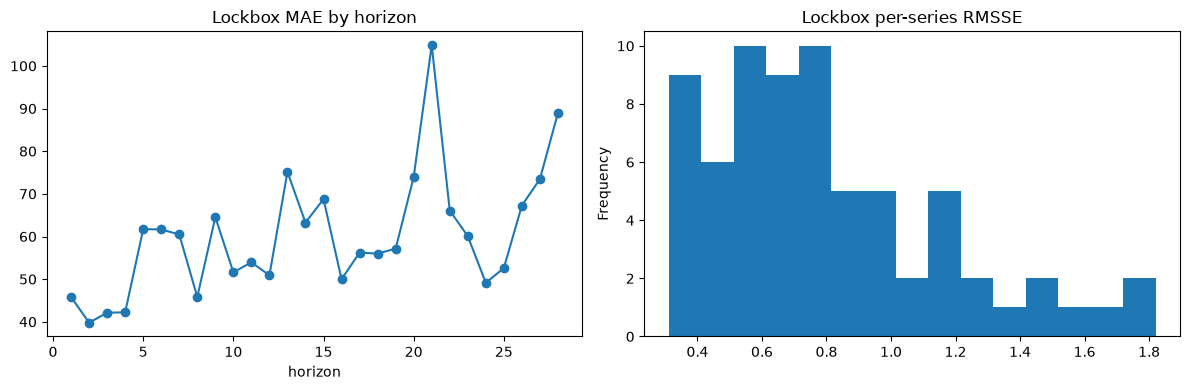

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4)); daily.plot(x='horizon',y='mae',marker='o',legend=False,title='Lockbox MAE by horizon',ax=axes[0]); learned.plot.hist(bins=15,title='Lockbox per-series RMSSE',ax=axes[1]); plt.tight_layout(); plt.show()

## Consumption boundary
**d_1914–d_1941 IS NOW CONSUMED.** It must never again be treated as validation or used to tune features, parameters, preprocessing, thresholds, baselines, strategy, or model family. Any weaknesses are limitations or hypotheses for genuinely new future data—not permission to redesign against this lockbox.